In [66]:
# Importação da biblioteca Pandas
import pandas as pd

In [67]:
# Pandas como biblioteca central para análise de dados
# Dataset é carregado diretamente de um repositório online

In [68]:
df = pd.read_csv("https://raw.githubusercontent.com/guilhermeonrails/data-jobs/refs/heads/main/salaries.csv")

In [69]:
# Inspeção inicial do dataset com df.head(), df.info(), df.describe() e df.shape()

In [70]:
# Exibe as 5 primeiras linhas do DataFrame
# Visão rápida dos dados
df.head()

,work_year,experience_level,employment_type,job_title,salary,salary_currency,salary_in_usd,employee_residence,remote_ratio,company_location,company_size
0,2025.0,SE,FT,Solutions Engineer,214000,USD,214000,US,100,US,M
1,2025.0,SE,FT,Solutions Engineer,136000,USD,136000,US,100,US,M
2,2025.0,MI,FT,Data Engineer,158800,USD,158800,AU,0,AU,M
3,2025.0,MI,FT,Data Engineer,139200,USD,139200,AU,0,AU,M
4,2025.0,EN,FT,Data Engineer,90000,USD,90000,US,0,US,M


In [71]:
# Mostra o resumo estrutural do DataFrame
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 133349 entries, 0 to 133348
Data columns (total 11 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   work_year           133339 non-null  float64
 1   experience_level    133349 non-null  object 
 2   employment_type     133349 non-null  object 
 3   job_title           133349 non-null  object 
 4   salary              133349 non-null  int64  
 5   salary_currency     133349 non-null  object 
 6   salary_in_usd       133349 non-null  int64  
 7   employee_residence  133349 non-null  object 
 8   remote_ratio        133349 non-null  int64  
 9   company_location    133349 non-null  object 
 10  company_size        133349 non-null  object 
dtypes: float64(1), int64(3), object(7)
memory usage: 11.2+ MB


In [72]:
# Gera estatísticas descritivas das colunas numéricas
df.describe()

,work_year,salary,salary_in_usd,remote_ratio
count,133339.000000,1.333490e+05,133349.000000,133349.000000
mean,2024.358770,1.632833e+05,157617.272098,20.905669
std,0.680627,2.173860e+05,74288.363097,40.590044
min,2020.000000,1.400000e+04,15000.000000,0.000000
25%,2024.000000,1.060200e+05,106000.000000,0.000000
50%,2024.000000,1.470000e+05,146206.000000,0.000000
75%,2025.000000,1.990000e+05,198000.000000,0.000000
max,2025.000000,3.040000e+07,800000.000000,100.000000


In [73]:
# Retorna o número de linhas e o número de colunas da base de dados
# Saber o tamanho do dataset
df.shape

(133349, 11)

In [74]:
linhas, colunas = df.shape[0], df.shape[1]
print("Linhas:", linhas)
print("Colunas:", colunas)

Linhas: 133349
Colunas: 11


In [75]:
df.columns

# Renomeando as colunas
new_columns = {
    'work_year': 'ano_trabalho',
    'experience_level': 'senioridade',
    'employment_type': 'contrato',
    'job_title': 'cargo',
    'salary': 'salario',
    'salary_currency': 'moeda',
    'salary_in_usd': 'usd',
    'employee_residence': 'residencia',
    'remote_ratio': 'remoto',
    'company_location': 'empresa',
    'company_size': 'tamanho_empresa'
}
df = df.rename(columns=new_columns)
df.columns

Index(['ano_trabalho', 'senioridade', 'contrato', 'cargo', 'salario', 'moeda',
       'usd', 'residencia', 'remoto', 'empresa', 'tamanho_empresa'],
      dtype='object')

In [76]:
df.columns

Index(['ano_trabalho', 'senioridade', 'contrato', 'cargo', 'salario', 'moeda',
       'usd', 'residencia', 'remoto', 'empresa', 'tamanho_empresa'],
      dtype='object')

In [77]:
#Identificando a distribuição das categorias

In [78]:
df["senioridade"].value_counts()

,count
senioridade,
SE,77241
MI,40465
EN,12443
EX,3200


In [79]:
df['contrato'].value_counts()

,count
contrato,
FT,132563
CT,394
PT,376
FL,16


In [80]:
df['remoto'].value_counts()

,count
remoto,
0,105312
100,27718
50,319


In [81]:
df['tamanho_empresa'].value_counts()

,count
tamanho_empresa,
M,129561
L,3574
S,214


In [82]:
#Padronização e tradução de categorias
df['tamanho_empresa'] = df['tamanho_empresa'].replace({
    'S': 'Pequena',
    'M': 'Média',
    'L': 'Grande'
})
df['tamanho_empresa'].value_counts()

,count
tamanho_empresa,
Média,129561
Grande,3574
Pequena,214


In [83]:
df['senioridade'] = df['senioridade'].replace({
    'SE': 'Sênior',
    'MI': 'Pleno',
    'EN': 'Júnior',
    'EX': 'Executivo'
})
df['senioridade'].value_counts()

,count
senioridade,
Sênior,77241
Pleno,40465
Júnior,12443
Executivo,3200


In [84]:
df['contrato'] = df['contrato'].replace({
    'FT': 'Tempo Integral',
    'CT': 'Contrato',
    'PT': 'Meio Período',
    'FL': 'Freelancer'
})
df['contrato'].value_counts()

,count
contrato,
Tempo Integral,132563
Contrato,394
Meio Período,376
Freelancer,16


In [85]:
df['remoto'] = df['remoto'].replace({
    0: 'Presencial',
    50: 'Híbrido',
    100: 'Remoto'
})
df['remoto'].value_counts()

,count
remoto,
Presencial,105312
Remoto,27718
Híbrido,319


In [86]:
# Revisão após tratamento dos dados

In [87]:
df.head()

,ano_trabalho,senioridade,contrato,cargo,salario,moeda,usd,residencia,remoto,empresa,tamanho_empresa
0,2025.0,Sênior,Tempo Integral,Solutions Engineer,214000,USD,214000,US,Remoto,US,Média
1,2025.0,Sênior,Tempo Integral,Solutions Engineer,136000,USD,136000,US,Remoto,US,Média
2,2025.0,Pleno,Tempo Integral,Data Engineer,158800,USD,158800,AU,Presencial,AU,Média
3,2025.0,Pleno,Tempo Integral,Data Engineer,139200,USD,139200,AU,Presencial,AU,Média
4,2025.0,Júnior,Tempo Integral,Data Engineer,90000,USD,90000,US,Presencial,US,Média


In [88]:
df.describe(include='object')

,senioridade,contrato,cargo,moeda,residencia,remoto,empresa,tamanho_empresa
count,133349,133349,133349,133349,133349,133349,133349,133349
unique,4,4,390,26,102,3,95,3
top,Sênior,Tempo Integral,Data Scientist,USD,US,Presencial,US,Média
freq,77241,132563,17314,126140,119579,105312,119641,129561


In [89]:
df.describe()

,ano_trabalho,salario,usd
count,133339.000000,1.333490e+05,133349.000000
mean,2024.358770,1.632833e+05,157617.272098
std,0.680627,2.173860e+05,74288.363097
min,2020.000000,1.400000e+04,15000.000000
25%,2024.000000,1.060200e+05,106000.000000
50%,2024.000000,1.470000e+05,146206.000000
75%,2025.000000,1.990000e+05,198000.000000
max,2025.000000,3.040000e+07,800000.000000


In [90]:
df.isnull()

,ano_trabalho,senioridade,contrato,cargo,salario,moeda,usd,residencia,remoto,empresa,tamanho_empresa
0,False,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...
133344,False,False,False,False,False,False,False,False,False,False,False
133345,False,False,False,False,False,False,False,False,False,False,False
133346,False,False,False,False,False,False,False,False,False,False,False
133347,False,False,False,False,False,False,False,False,False,False,False


In [91]:
df.head()

,ano_trabalho,senioridade,contrato,cargo,salario,moeda,usd,residencia,remoto,empresa,tamanho_empresa
0,2025.0,Sênior,Tempo Integral,Solutions Engineer,214000,USD,214000,US,Remoto,US,Média
1,2025.0,Sênior,Tempo Integral,Solutions Engineer,136000,USD,136000,US,Remoto,US,Média
2,2025.0,Pleno,Tempo Integral,Data Engineer,158800,USD,158800,AU,Presencial,AU,Média
3,2025.0,Pleno,Tempo Integral,Data Engineer,139200,USD,139200,AU,Presencial,AU,Média
4,2025.0,Júnior,Tempo Integral,Data Engineer,90000,USD,90000,US,Presencial,US,Média


In [92]:
df.isnull().sum()

,0
ano_trabalho,10
senioridade,0
contrato,0
cargo,0
salario,0
moeda,0
usd,0
residencia,0
remoto,0
empresa,0


In [93]:
df['ano_trabalho'].unique()

array([2025.,   nan, 2024., 2022., 2023., 2020., 2021.])

In [94]:
df[df.isnull().any(axis=1)]

,ano_trabalho,senioridade,contrato,cargo,salario,moeda,usd,residencia,remoto,empresa,tamanho_empresa
5588,NaN,Sênior,Tempo Integral,Product Manager,184500,USD,184500,US,Presencial,US,Média
59692,NaN,Pleno,Tempo Integral,Engineer,110000,USD,110000,DE,Presencial,DE,Média
59710,NaN,Júnior,Tempo Integral,Data Scientist,208800,USD,208800,US,Presencial,US,Média
59759,NaN,Sênior,Tempo Integral,Software Engineer,135000,USD,135000,US,Presencial,US,Média
59789,NaN,Sênior,Tempo Integral,Engineer,112000,USD,112000,US,Presencial,US,Média
131000,NaN,Sênior,Tempo Integral,Machine Learning Engineer,163800,USD,163800,US,Presencial,US,Média
131006,NaN,Sênior,Tempo Integral,Data Analytics Manager,204500,USD,204500,US,Presencial,US,Média
133054,NaN,Júnior,Tempo Integral,Data Scientist,40000,USD,40000,JP,Remoto,MY,Grande
133281,NaN,Pleno,Tempo Integral,Machine Learning Engineer,180000,PLN,46597,PL,Remoto,PL,Grande
133317,NaN,Pleno,Tempo Integral,Data Scientist,130000,USD,130000,US,Híbrido,US,Grande


In [95]:
# Importação da biblioteca Numpy
import numpy as np

# Criação de um dataframe de teste para usar de exemplo
df_salarios = pd.DataFrame({
    'nome': ['João', 'Ana', 'Carlos', 'Yuri', 'Serena', 'Theo'],
    'salario': [4000, np.nan, 5200, np.nan, 8500, np.nan]
})

# Calcula a média salarial e substitui os nulos pela média e arredonda os valores
df_salarios['salario_media'] = df_salarios['salario'].fillna(df_salarios['salario'].mean().round(2))

# Calcula mediana e substitui os nulos pela mediana
df_salarios['salario_mediana'] = df_salarios['salario'].fillna(df_salarios['salario'].median())
df_salarios

,nome,salario,salario_media,salario_mediana
0,João,4000.0,4000.0,4000.0
1,Ana,NaN,5900.0,5200.0
2,Carlos,5200.0,5200.0,5200.0
3,Yuri,NaN,5900.0,5200.0
4,Serena,8500.0,8500.0,8500.0
5,Theo,NaN,5900.0,5200.0


In [96]:
df_temperatura = pd.DataFrame({
    'dia_semana': ['segunda', 'terça', 'quarta', 'quinta', 'sexta', 'sábado', 'domingo'],
    'temperatura': [32, np.nan, np.nan, 28, 27, np.nan, 24]
})

df_temperatura['preenchido_ffill'] = df_temperatura['temperatura'].ffill()
df_temperatura

,dia_semana,temperatura,preenchido_ffill
0,segunda,32.0,32.0
1,terça,NaN,32.0
2,quarta,NaN,32.0
3,quinta,28.0,28.0
4,sexta,27.0,27.0
5,sábado,NaN,27.0
6,domingo,24.0,24.0


In [97]:
df_temperatura = pd.DataFrame({
    'dia_semana': ['segunda', 'terça', 'quarta', 'quinta', 'sexta', 'sábado', 'domingo'],
    'temperatura': [32, np.nan, np.nan, 28, 27, np.nan, 24]
})

df_temperatura['preenchido_bfill'] = df_temperatura['temperatura'].bfill()
df_temperatura

,dia_semana,temperatura,preenchido_bfill
0,segunda,32.0,32.0
1,terça,NaN,28.0
2,quarta,NaN,28.0
3,quinta,28.0,28.0
4,sexta,27.0,27.0
5,sábado,NaN,24.0
6,domingo,24.0,24.0


In [98]:
df_cidades = pd.DataFrame({
    'nome': ['Ana', 'Bruno', 'Carlos', 'Diana', 'Eduardo'],
    'cidade': ['São Paulo', np.nan, 'Curitiba', np.nan, 'Salvador']
})

df_cidades['cidade_corrigida'] = df_cidades['cidade'].fillna('Não informado')

df_cidades

,nome,cidade,cidade_corrigida
0,Ana,São Paulo,São Paulo
1,Bruno,NaN,Não informado
2,Carlos,Curitiba,Curitiba
3,Diana,NaN,Não informado
4,Eduardo,Salvador,Salvador


In [99]:
df_limpeza = df.dropna()
df_limpeza.isnull().sum()

,0
ano_trabalho,0
senioridade,0
contrato,0
cargo,0
salario,0
moeda,0
usd,0
residencia,0
remoto,0
empresa,0


In [100]:
df_limpeza.head()

,ano_trabalho,senioridade,contrato,cargo,salario,moeda,usd,residencia,remoto,empresa,tamanho_empresa
0,2025.0,Sênior,Tempo Integral,Solutions Engineer,214000,USD,214000,US,Remoto,US,Média
1,2025.0,Sênior,Tempo Integral,Solutions Engineer,136000,USD,136000,US,Remoto,US,Média
2,2025.0,Pleno,Tempo Integral,Data Engineer,158800,USD,158800,AU,Presencial,AU,Média
3,2025.0,Pleno,Tempo Integral,Data Engineer,139200,USD,139200,AU,Presencial,AU,Média
4,2025.0,Júnior,Tempo Integral,Data Engineer,90000,USD,90000,US,Presencial,US,Média


In [101]:
df_limpeza.info()

<class 'pandas.core.frame.DataFrame'>
Index: 133339 entries, 0 to 133348
Data columns (total 11 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   ano_trabalho     133339 non-null  float64
 1   senioridade      133339 non-null  object 
 2   contrato         133339 non-null  object 
 3   cargo            133339 non-null  object 
 4   salario          133339 non-null  int64  
 5   moeda            133339 non-null  object 
 6   usd              133339 non-null  int64  
 7   residencia       133339 non-null  object 
 8   remoto           133339 non-null  object 
 9   empresa          133339 non-null  object 
 10  tamanho_empresa  133339 non-null  object 
dtypes: float64(1), int64(2), object(8)
memory usage: 12.2+ MB


In [102]:
df_limpeza = df_limpeza.assign(ano_trabalho = df_limpeza['ano_trabalho'].astype('int64'))

In [103]:
df_limpeza.head()

,ano_trabalho,senioridade,contrato,cargo,salario,moeda,usd,residencia,remoto,empresa,tamanho_empresa
0,2025,Sênior,Tempo Integral,Solutions Engineer,214000,USD,214000,US,Remoto,US,Média
1,2025,Sênior,Tempo Integral,Solutions Engineer,136000,USD,136000,US,Remoto,US,Média
2,2025,Pleno,Tempo Integral,Data Engineer,158800,USD,158800,AU,Presencial,AU,Média
3,2025,Pleno,Tempo Integral,Data Engineer,139200,USD,139200,AU,Presencial,AU,Média
4,2025,Júnior,Tempo Integral,Data Engineer,90000,USD,90000,US,Presencial,US,Média


In [104]:
df_limpeza.info()

<class 'pandas.core.frame.DataFrame'>
Index: 133339 entries, 0 to 133348
Data columns (total 11 columns):
 #   Column           Non-Null Count   Dtype 
---  ------           --------------   ----- 
 0   ano_trabalho     133339 non-null  int64 
 1   senioridade      133339 non-null  object
 2   contrato         133339 non-null  object
 3   cargo            133339 non-null  object
 4   salario          133339 non-null  int64 
 5   moeda            133339 non-null  object
 6   usd              133339 non-null  int64 
 7   residencia       133339 non-null  object
 8   remoto           133339 non-null  object
 9   empresa          133339 non-null  object
 10  tamanho_empresa  133339 non-null  object
dtypes: int64(3), object(8)
memory usage: 12.2+ MB


In [105]:
df_limpeza.head()

,ano_trabalho,senioridade,contrato,cargo,salario,moeda,usd,residencia,remoto,empresa,tamanho_empresa
0,2025,Sênior,Tempo Integral,Solutions Engineer,214000,USD,214000,US,Remoto,US,Média
1,2025,Sênior,Tempo Integral,Solutions Engineer,136000,USD,136000,US,Remoto,US,Média
2,2025,Pleno,Tempo Integral,Data Engineer,158800,USD,158800,AU,Presencial,AU,Média
3,2025,Pleno,Tempo Integral,Data Engineer,139200,USD,139200,AU,Presencial,AU,Média
4,2025,Júnior,Tempo Integral,Data Engineer,90000,USD,90000,US,Presencial,US,Média


<Axes: title={'center': 'Distribuição_Senioridade'}, xlabel='senioridade'>

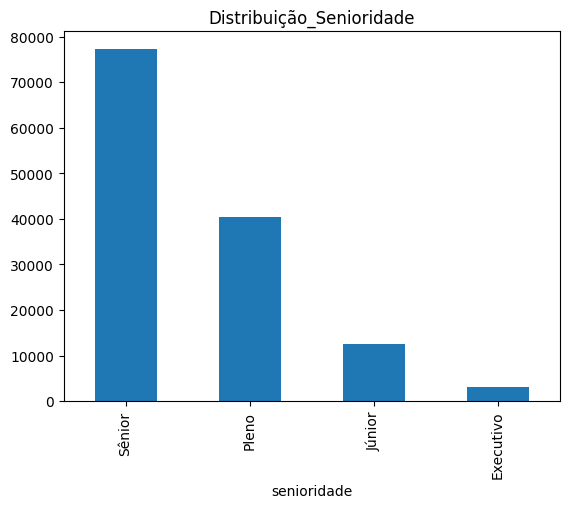

In [106]:
df_limpeza['senioridade'].value_counts().plot(kind='bar', title='Distribuição_Senioridade')

In [107]:
# Importação da biblioteca Seaborn
import seaborn as sns

<Axes: xlabel='senioridade', ylabel='usd'>

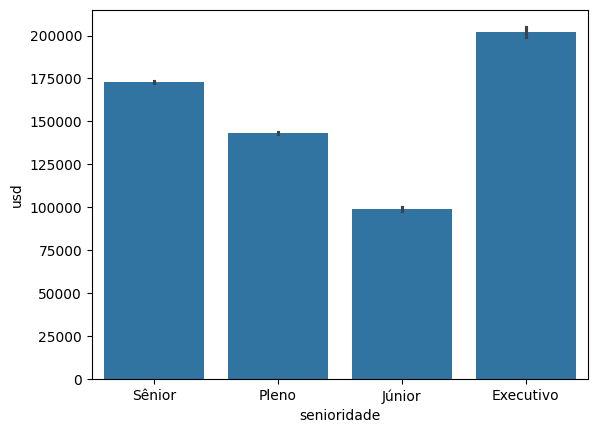

In [108]:
sns.barplot(data=df_limpeza, x='senioridade', y='usd')

In [109]:
# Importação da biblioteca Matplotlib
import matplotlib.pyplot as plt

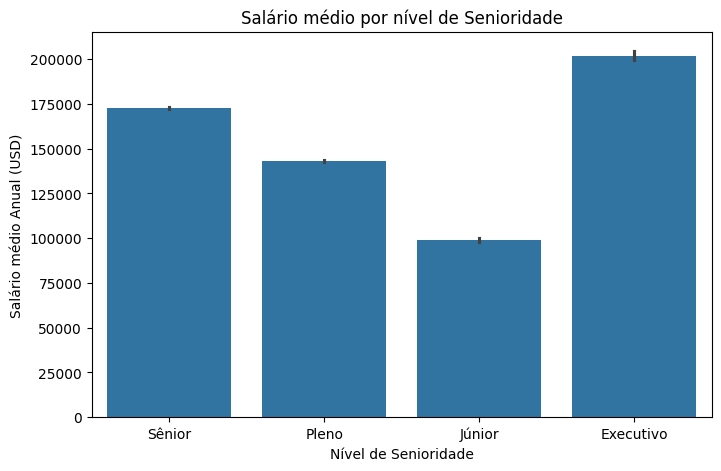

In [110]:
plt.figure(figsize=(8, 5))
sns.barplot(data=df_limpeza, x='senioridade', y='usd')
plt.title('Salário médio por nível de Senioridade')
plt.xlabel('Nível de Senioridade')
plt.ylabel('Salário médio Anual (USD)')
plt.show()

In [111]:
df_limpeza.groupby('senioridade')['usd'].mean().sort_values(ascending=False)

,usd
senioridade,
Executivo,202027.667813
Sênior,172850.838301
Pleno,143044.845979
Júnior,99034.963267


In [112]:
ordem = df_limpeza.groupby('senioridade')['usd'].mean().sort_values(ascending=False).index

In [113]:
ordem

Index(['Executivo', 'Sênior', 'Pleno', 'Júnior'], dtype='object', name='senioridade')

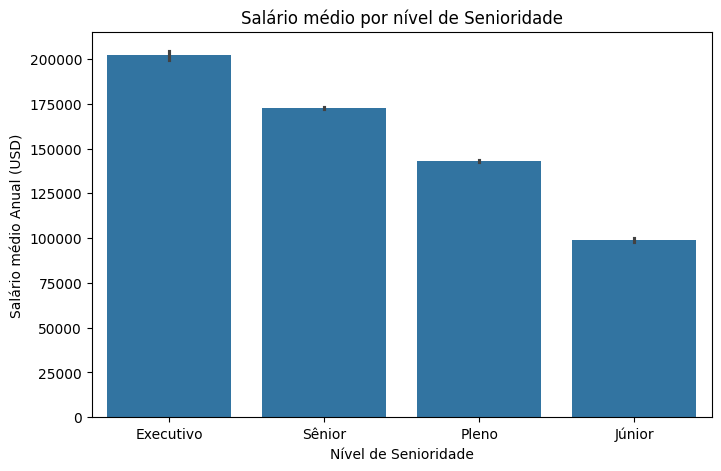

In [114]:
plt.figure(figsize=(8, 5))
sns.barplot(data=df_limpeza, x='senioridade', y='usd', order = ordem)
plt.title('Salário médio por nível de Senioridade')
plt.xlabel('Nível de Senioridade')
plt.ylabel('Salário médio Anual (USD)')
plt.show()

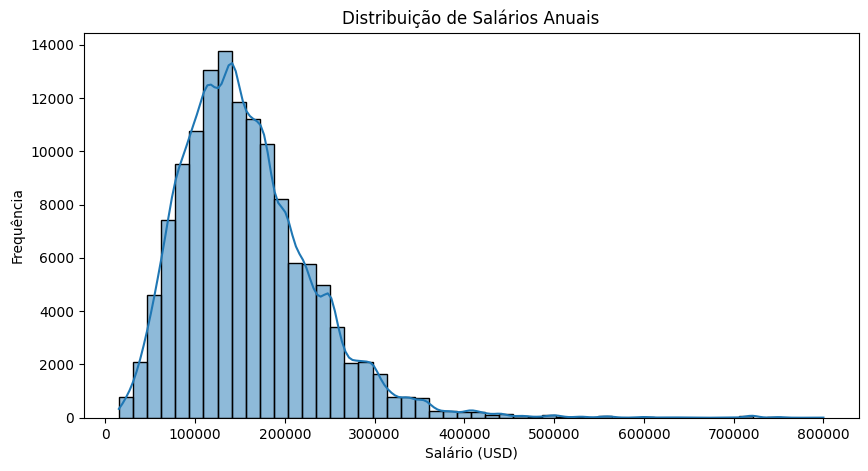

In [115]:
plt.figure(figsize=(10, 5))
sns.histplot(df_limpeza['usd'], bins = 50, kde=True)
plt.title('Distribuição de Salários Anuais')
plt.xlabel('Salário (USD)')
plt.ylabel('Frequência')
plt.show()

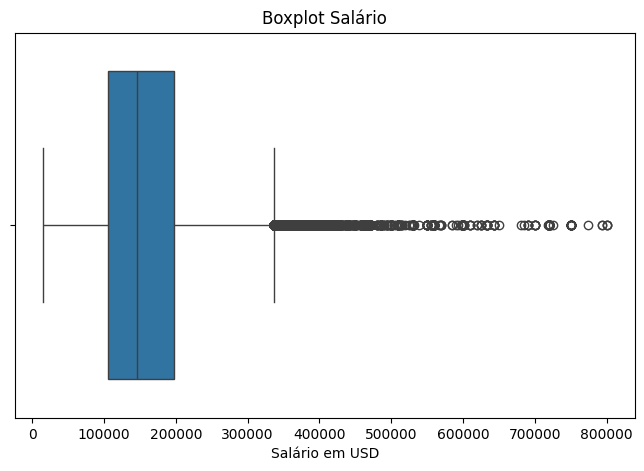

In [116]:
plt.figure(figsize=(8, 5))
sns.boxplot(x = df_limpeza['usd'])
plt.title('Boxplot Salário')
plt.xlabel('Salário em USD')
plt.show()

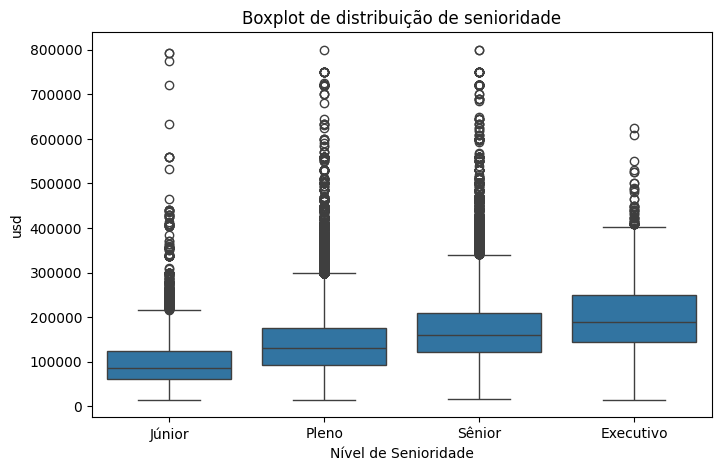

In [117]:
ordem_senioridade = ['Júnior', 'Pleno', 'Sênior', 'Executivo']
plt.figure(figsize=(8, 5))
sns.boxplot(x = 'senioridade', y = 'usd', data = df_limpeza, order = ordem_senioridade)
plt.title('Boxplot de distribuição de senioridade')
plt.xlabel('Nível de Senioridade')
plt.show()

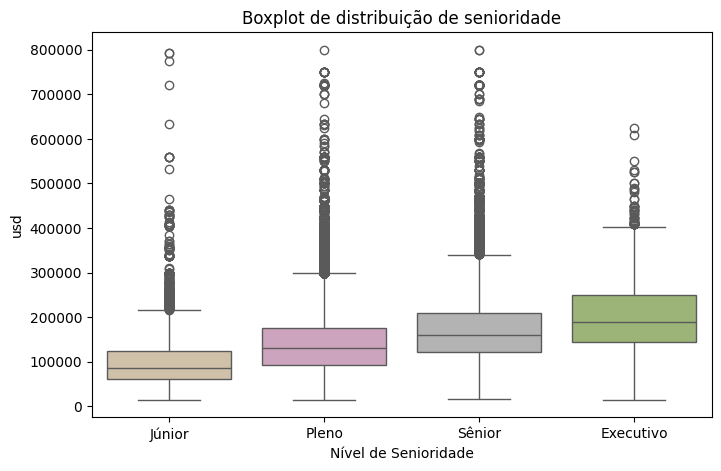

In [118]:
ordem_senioridade = ['Júnior', 'Pleno', 'Sênior', 'Executivo']
plt.figure(figsize=(8, 5))
cores_paleta = [
    "#B3B3B3",
    "#D49DBF",
    "#D5C1A4",
    "#A0BE6E",
]
sns.boxplot(x = 'senioridade', y = 'usd', data = df_limpeza, order = ordem_senioridade, palette = cores_paleta, hue='senioridade')
plt.title('Boxplot de distribuição de senioridade')
plt.xlabel('Nível de Senioridade')
plt.show()

In [119]:
# Importação da biblioteca Plotly
import plotly.express as px

In [120]:
senioridade_media_salario = df_limpeza.groupby('senioridade')['usd'].mean().sort_values(ascending=False).reset_index()

fig = px.bar(senioridade_media_salario,
             x='senioridade',
             y='usd',
             title='Média Salarial por Senioridade',
             labels={'senioridade': 'Nível de Senioridade', 'usd': 'Média Salarial Anual (USD)'})

fig.show()

In [121]:
remoto_contagem = df_limpeza['remoto'].value_counts().reset_index()
remoto_contagem.columns = ['tipo_trabalho', 'quantidade']

fig = px.pie(remoto_contagem,
             names = 'tipo_trabalho',
             values = 'quantidade',
             title='Proporção do tipos de trabalho')
fig.show()

In [122]:
remoto_contagem = df_limpeza['remoto'].value_counts().reset_index()
remoto_contagem.columns = ['tipo_trabalho', 'quantidade']

fig = px.pie(remoto_contagem,
             names = 'tipo_trabalho',
             values = 'quantidade',
             title='Proporção do tipos de trabalho',
             hole = 0.5)
fig.show()

In [123]:
remoto_contagem = df_limpeza['remoto'].value_counts().reset_index()
remoto_contagem.columns = ['tipo_trabalho', 'quantidade']

fig = px.pie(remoto_contagem,
             names = 'tipo_trabalho',
             values = 'quantidade',
             title='Proporção do tipos de trabalho',
             hole = 0.5)
fig.update_traces(textinfo='percent + label')
fig.show()

In [124]:
# Download da biblioteca pycountry
pip install pycountry

SyntaxError: invalid syntax (ipython-input-3493829999.py, line 2)

In [ ]:
# Importação da biblioteca Pycountry
import pycountry

In [ ]:
# Função para converter ISO-2 para ISO-3
def iso2_to_iso3(code):
    try:
        return pycountry.countries.get(alpha_2=code).alpha_3
    except:
        return None

# Criar nova coluna com código ISO-3
df_limpeza['residencia_iso3'] = df_limpeza['residencia'].apply(iso2_to_iso3)

# Calcular média salarial por país (ISO-3)
df_ds = df_limpeza[df_limpeza['cargo'] == 'Data Scientist']
media_ds_pais = df_ds.groupby('residencia_iso3')['usd'].mean().reset_index()

# Gerar o mapa
fig = px.choropleth(media_ds_pais,
                    locations='residencia_iso3',
                    color='usd',
                    color_continuous_scale='rdylgn',
                    title='Salário médio de Cientista de Dados por país',
                    labels={'usd': 'Salário médio (USD)', 'residencia_iso3': 'País'})

fig.show()

In [ ]:
df_limpeza.head()

In [ ]:
df_limpeza.to_csv('dados_empresa_final', index=False)